# K-means Cluster Heatmaps

In [44]:
import pandas as pd

expression = pd.read_csv("expression.txt", sep="\t")
expression = expression.set_index("Hugo_Symbol")
expression = expression.drop("Entrez_Gene_Id", axis=1)
# print(expression.head())

In [2]:
# patients = pd.read_csv("patient_bchm_recurr_cohorts.csv")
# print(patients.head())
# print()
# bchm_early_pts = patients[patients["Days to Bchm Recurr"]<100]
# bchm_late_pts = patients[patients["Days to Bchm Recurr"]>100]
# bchem_early_ids = bchm_early_pts["Patient (Firehose)"].to_list()
# bchem_late_ids = bchm_late_pts["Patient (Firehose)"].to_list()
# print(bchem_early_ids)
# print()
# print(bchem_late_ids)

In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv("prad_tcga_clinical_data.tsv", sep="\t")
print(df.columns)

df = df.rename(columns={
    'Patient ID': 'PATIENT_ID',
    'Radical Prostatectomy Gleason Score for Prostate Cancer': 'GLEASON_SCORE'
})

# df['GLEASON_SCORE']

df = df[['PATIENT_ID', 'GLEASON_SCORE']].copy()

# one‐hot/binary columns for 6, 7, 8 and “9 or above”
df['GLEASON_6']    = (df['GLEASON_SCORE'] == 6).astype(int)
df['GLEASON_7']    = (df['GLEASON_SCORE'] == 7).astype(int)
df['GLEASON_8']    = (df['GLEASON_SCORE'] == 8).astype(int)
df['GLEASON_9_10'] = (df['GLEASON_SCORE'] >= 9).astype(int)

# Save to CSV
df.to_csv("gleason_score_bchem_cohorts.csv", index=False)

# print(df.head())


Index(['Study ID', 'Patient ID', 'Sample ID', 'Diagnosis Age',
       'Neoplasm Disease Stage American Joint Committee on Cancer Code',
       'American Joint Committee on Cancer Publication Version Type',
       'Biochemical Recurrence Indicator', 'Bone Scan Result', 'Cancer Type',
       'Cancer Type Detailed', 'Cause of death source',
       'Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage',
       'Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage',
       'Neoplasm American Joint Committee on Cancer Clinical Primary Tumor T Stage',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage',
       'Ct scan ab pelvis indicator', 'Ct scan ab pelvis results',
       'Days to biochemical recurrence first', 'Days to bone Scan performed',
       'Days to Sample Collection.', 'Days to ct scan ab pelvis',
       'Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value',
       'Days to mri', 'Days

In [40]:
patients = pd.read_csv("gleason_score_bchem_cohorts.csv")
print(patients.head())
print()
gleason_c1 = patients[patients["GLEASON_SCORE"]==6]
gleason_c2 = patients[patients["GLEASON_SCORE"]==7]
gleason_c3 = patients[patients["GLEASON_SCORE"]==8]
gleason_c4 = patients[(patients["GLEASON_SCORE"] == 9) | (patients["GLEASON_SCORE"] == 10)]

gleason_c1_ids = gleason_c1["PATIENT_ID"].to_list()
gleason_c2_ids = gleason_c2["PATIENT_ID"].to_list()
gleason_c3_ids = gleason_c3["PATIENT_ID"].to_list()
gleason_c4_ids = gleason_c4["PATIENT_ID"].to_list()

print(len(gleason_c1_ids))
print(len(gleason_c2_ids))
print(len(gleason_c3_ids))
print(len(gleason_c4_ids))


# print(gleason_c4_ids)

     PATIENT_ID  GLEASON_SCORE  GLEASON_6  GLEASON_7  GLEASON_8  GLEASON_9_10
0  TCGA-2A-A8VL              6          1          0          0             0
1  TCGA-2A-A8VO              6          1          0          0             0
2  TCGA-2A-A8VT              9          0          0          0             1
3  TCGA-2A-A8VV              6          1          0          0             0
4  TCGA-2A-A8VX              8          0          0          1             0

45
250
64
142


In [66]:
# early_bchem = expression[expression.columns.intersection(bchem_early_ids)]
# early_bchem = early_bchem.dropna(axis=0)
# late_bchem = expression[expression.columns.intersection(bchem_late_ids)]
# late_bchem = late_bchem.dropna(axis=0)
# print(early_bchem.head())
# print()
# print(late_bchem.head())

In [ ]:
# print(expression.columns[:5])
# print(bchem_c1_ids[:5])

# expression.columns = expression.columns.str[:12]
# bchem_c1_ids = [x[:12] for x in bchem_c1_ids]

# print("Matches in cohort 1:", expression.columns.intersection(bchem_c1_ids).tolist())


Index(['TCGA-2A-A8VL', 'TCGA-2A-A8VO', 'TCGA-2A-A8VT', 'TCGA-2A-A8VV',
       'TCGA-2A-A8VX'],
      dtype='object')
['TCGA-ZG-A9L9', 'TCGA-EJ-A65F', 'TCGA-YL-A9WJ', 'TCGA-EJ-5504', 'TCGA-J4-AATZ']
Matches in cohort 1: ['TCGA-EJ-5504', 'TCGA-EJ-5519', 'TCGA-EJ-7783', 'TCGA-EJ-A65F', 'TCGA-EJ-A8FP', 'TCGA-J4-AATZ', 'TCGA-J9-A52B', 'TCGA-J9-A52E', 'TCGA-J9-A8CL', 'TCGA-V1-A8WW', 'TCGA-V1-A9O5', 'TCGA-V1-A9OL', 'TCGA-V1-A9ZI', 'TCGA-VP-A878', 'TCGA-XK-AAJR', 'TCGA-YJ-A8SW', 'TCGA-YL-A9WJ', 'TCGA-ZG-A9L9']


In [45]:
expression = expression.loc[:, ~expression.columns.duplicated()]

c1_gleason = expression[expression.columns.intersection(gleason_c1_ids)]
c1_gleason = c1_gleason.dropna(axis=0)

c2_gleason = expression[expression.columns.intersection(gleason_c2_ids)]
c2_gleason = c2_gleason.dropna(axis=0)

c3_gleason = expression[expression.columns.intersection(gleason_c3_ids)]
c3_gleason = c3_gleason.dropna(axis=0)

c4_gleason = expression[expression.columns.intersection(gleason_c4_ids)]
c4_gleason = c4_gleason.dropna(axis=0)

# c5_bchem = expression[expression.columns.intersection(bchem_c5_ids)]
# c5_bchem = c5_bchem.dropna(axis=0)

print(c1_gleason.head())
print()
print(c2_gleason.head())
print()
print(c3_gleason.head())
print()
print(c4_gleason.head())

             TCGA-2A-A8VL  TCGA-2A-A8VO  TCGA-2A-A8VV  TCGA-2A-AAYO  \
Hugo_Symbol                                                           
UBE2Q2P2          -0.0083       -0.2773       -0.0837       -0.0076   
SSX9              -0.0474       -0.0474       -0.0474       -0.0474   
EZHIP             -0.3584       -0.2411        1.0813        1.7024   
EFCAB8            -0.1967        1.9697       -0.2167       -0.4290   
SDR16C6P          -0.1839       -0.1839       -0.1839       -0.1839   

             TCGA-2A-AAYU  TCGA-CH-5738  TCGA-CH-5768  TCGA-EJ-5517  \
Hugo_Symbol                                                           
UBE2Q2P2          -0.1070       -0.9472       -0.5842       -0.6169   
SSX9              -0.0474       -0.0474       -0.0474       -0.0474   
EZHIP              0.2327       -0.5013       -0.2337       -0.7616   
EFCAB8             0.1437       -0.1291       -0.2770       -0.4290   
SDR16C6P          -0.1839       -0.1839       -0.1839       -0.1839   

    

In [47]:
print(c1_gleason.dtypes)

TCGA-2A-A8VL    float64
TCGA-2A-A8VO    float64
TCGA-2A-A8VV    float64
TCGA-2A-AAYO    float64
TCGA-2A-AAYU    float64
TCGA-CH-5738    float64
TCGA-CH-5768    float64
TCGA-EJ-5517    float64
TCGA-EJ-7321    float64
TCGA-EJ-A65M    float64
TCGA-EJ-AB20    float64
TCGA-EJ-AB27    float64
TCGA-FC-A8O0    float64
TCGA-G9-6342    float64
TCGA-G9-6347    float64
TCGA-G9-6371    float64
TCGA-G9-7509    float64
TCGA-H9-A6BX    float64
TCGA-HC-7075    float64
TCGA-HC-7077    float64
TCGA-HC-7209    float64
TCGA-HC-7748    float64
TCGA-HC-8213    float64
TCGA-HC-8258    float64
TCGA-HC-8259    float64
TCGA-HI-7170    float64
TCGA-J4-A67Q    float64
TCGA-J4-A83K    float64
TCGA-J4-AATV    float64
TCGA-J4-AAU2    float64
TCGA-J9-A8CN    float64
TCGA-M7-A720    float64
TCGA-QU-A6IO    float64
TCGA-QU-A6IP    float64
TCGA-V1-A8MF    float64
TCGA-V1-A8MK    float64
TCGA-V1-A8WN    float64
TCGA-V1-A8WS    float64
TCGA-V1-A9OF    float64
TCGA-V1-A9OQ    float64
TCGA-V1-A9OT    float64
TCGA-VP-A87E    

In [ ]:
import numpy as np
import pandas as pd
# outliers adjustment code using IQR method (can't use mean method because of large outliers)

def replace_outliers_vectorized(df: pd.DataFrame, threshold: float = 1):
    df_clean = df.copy()

    # Convert df to NumPy array for speed
    data = df_clean.to_numpy()
    # print(data)
    # Compute IQR-based bounds row-wise
    Q1 = np.quantile(data, 0.25, axis=1)
    Q3 = np.quantile(data, 0.75, axis=1)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    medians = np.median(data, axis=1)

    # Build mask of outliers
    outliers = (data < lower_bound[:, np.newaxis]) | (data > upper_bound[:, np.newaxis])

    # Replace outliers with row-wise medians
    data[outliers] = np.broadcast_to(medians[:, np.newaxis], data.shape)[outliers]

    # Convert back to DataFrame
    return pd.DataFrame(data, index=df.index, columns=df.columns)

adjusted_c1 = replace_outliers_vectorized(c1_gleason)
adjusted_c2 = replace_outliers_vectorized(c2_gleason)
adjusted_c3 = replace_outliers_vectorized(c3_gleason)
adjusted_c4 = replace_outliers_vectorized(c4_gleason)


# print(adjusted_c1.head())


[[-0.0083 -0.2773 -0.0837 ... -0.0268  0.3408 -0.1727]
 [-0.0474 -0.0474 -0.0474 ... -0.0474 -0.0474 -0.0474]
 [-0.3584 -0.2411  1.0813 ...  2.8416 -0.2889 -0.1182]
 ...
 [ 0.6222 -1.1407 -0.6526 ... -0.2807 -0.6561 -0.2677]
 [-1.4535 -0.8303  1.0471 ... -0.5741  0.0397 -0.4084]
 [ 0.2961  0.7903 -0.6555 ...  2.0786  0.0795 -0.6457]]
[[ 1.5382  0.371  -0.7975 ... -0.1691 -0.6517 -0.3723]
 [-0.0474 -0.0474 -0.0474 ... -0.0474 -0.0474 -0.0474]
 [ 0.7176  0.2356 -0.4495 ... -0.7616  0.5988  0.4801]
 ...
 [-0.8884 -1.4274 -0.8283 ... -1.7506 -0.8929  0.658 ]
 [ 1.6448 -0.5288  0.3836 ... -1.4061 -0.238  -0.6097]
 [-0.7358  1.9323 -0.5365 ...  1.8002  0.011  -0.6416]]
[[-0.6895 -0.2671 -0.4098 ... -0.1367  0.7533 -0.3521]
 [-0.0474 -0.0474 -0.0474 ... -0.0474 -0.0474 -0.0474]
 [-0.7616 -0.4224 -0.7616 ...  0.2352 -0.4067  0.1412]
 ...
 [-1.187  -0.6896  2.0004 ...  0.0697  0.019   0.8664]
 [-0.3152 -0.0326  2.3718 ... -1.129   1.1616 -0.3505]
 [-0.696  -0.3475  1.2139 ... -0.5283  1.3475 -0

In [13]:
# print(c1_bchem.loc["CPLX2"])
# sns.barplot(c1_bchem.loc["CPLX2"])
# print(adjusted_c1.loc["CPLX2"])
# sns.barplot(adjusted_c1.loc["CPLX2"])

In [55]:
adjusted_c1["c1 Average"] = adjusted_c1.mean(axis=1)
# print(early_bchem.head())
adjusted_c2["c2 Average"] = adjusted_c2.mean(axis=1)
# print(late_bchem.head())
adjusted_c3["c3 Average"] = adjusted_c3.mean(axis=1)
adjusted_c4["c4 Average"] = adjusted_c4.mean(axis=1)
# adjusted_c5["c5 Average"] = adjusted_c5.mean(axis=1)

expression = pd.DataFrame()
expression["Gleason 6 Average"] = adjusted_c1[["c1 Average"]] 
expression["Gleason 7 Average"] = adjusted_c2[["c2 Average"]] 
expression["Gleason 8 Average"] = adjusted_c3[["c3 Average"]] 
expression["Gleason 9+10 Average"] = adjusted_c4[["c4 Average"]] 
# expression["c5 Average"] = adjusted_c5[["c5 Average"]]
# combined_df = append(late_bchem[["Late Average"]]
print(expression.head())

             Gleason 6 Average  Gleason 7 Average  Gleason 8 Average  \
Hugo_Symbol                                                            
UBE2Q2P2             -0.342180          -0.386951          -0.134416   
SSX9                 -0.047400          -0.047400          -0.047400   
EZHIP                -0.086533          -0.280168          -0.266733   
EFCAB8               -0.078924          -0.210606          -0.016356   
SDR16C6P             -0.183900          -0.183900          -0.183900   

             Gleason 9+10 Average  
Hugo_Symbol                        
UBE2Q2P2                 0.038309  
SSX9                    -0.047400  
EZHIP                   -0.329352  
EFCAB8                  -0.063190  
SDR16C6P                -0.183900  


In [56]:
expression.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18397 entries, UBE2Q2P2 to TPTEP1
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gleason 6 Average     18397 non-null  float64
 1   Gleason 7 Average     18397 non-null  float64
 2   Gleason 8 Average     18397 non-null  float64
 3   Gleason 9+10 Average  18397 non-null  float64
dtypes: float64(4)
memory usage: 718.6+ KB


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

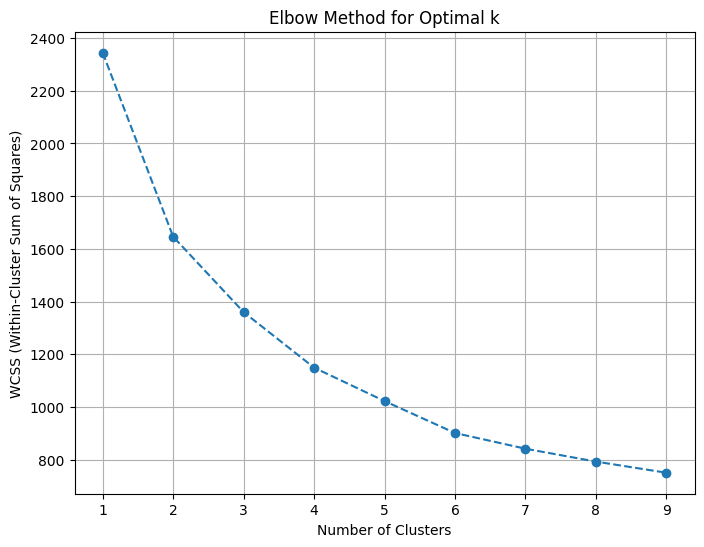

In [58]:
data = expression

# List to store WCSS for each number of clusters
wcss = []

# Loop over possible values of k (number of clusters)
for num_clusters in range(1, 10):  # You can adjust the range based on your data
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)  # WCSS is stored in inertia_

# Plot the Elbow plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, 10), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(np.arange(1, 10))
plt.grid(True)
plt.show()

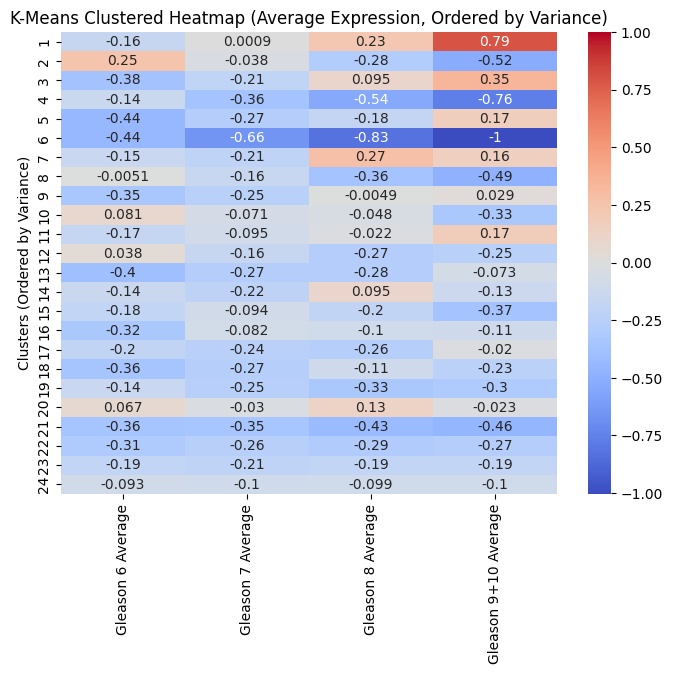

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# data = expression
# Filter only columns containing "Average" BEFORE clustering
average_data = data.loc[:, data.columns.str.contains("Average")].copy()

# Number of clusters
num_clusters = 24

# Run KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=100)
clusters = kmeans.fit_predict(average_data)

# Add cluster labels to the filtered data
average_data["Cluster"] = clusters

# Group by cluster and compute mean expression per cluster
clustered_data = average_data.groupby("Cluster").mean()

# Compute variance across columns for each cluster
cluster_variances = clustered_data.var(axis=1)

# Sort clusters by decreasing variance
sorted_clusters = cluster_variances.sort_values(ascending=False).index

# Create mapping from old cluster label to new label (ordered by variance)
cluster_mapping = {old: new for new, old in enumerate(sorted_clusters, start=1)}

# Apply new cluster label mapping
average_data["Cluster"] = average_data["Cluster"].map(cluster_mapping)

# Recompute cluster means using remapped cluster labels
clustered_data = average_data.groupby("Cluster").mean()

# Sort clustered_data rows by new cluster label (which is already ordered by variance)
clustered_data = clustered_data.loc[sorted(clustered_data.index)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(clustered_data, cmap="coolwarm", xticklabels=True, yticklabels=True, annot=True, vmax=1)

plt.title("K-Means Clustered Heatmap (Average Expression, Ordered by Variance)")
plt.ylabel("Clusters (Ordered by Variance)")
plt.show()


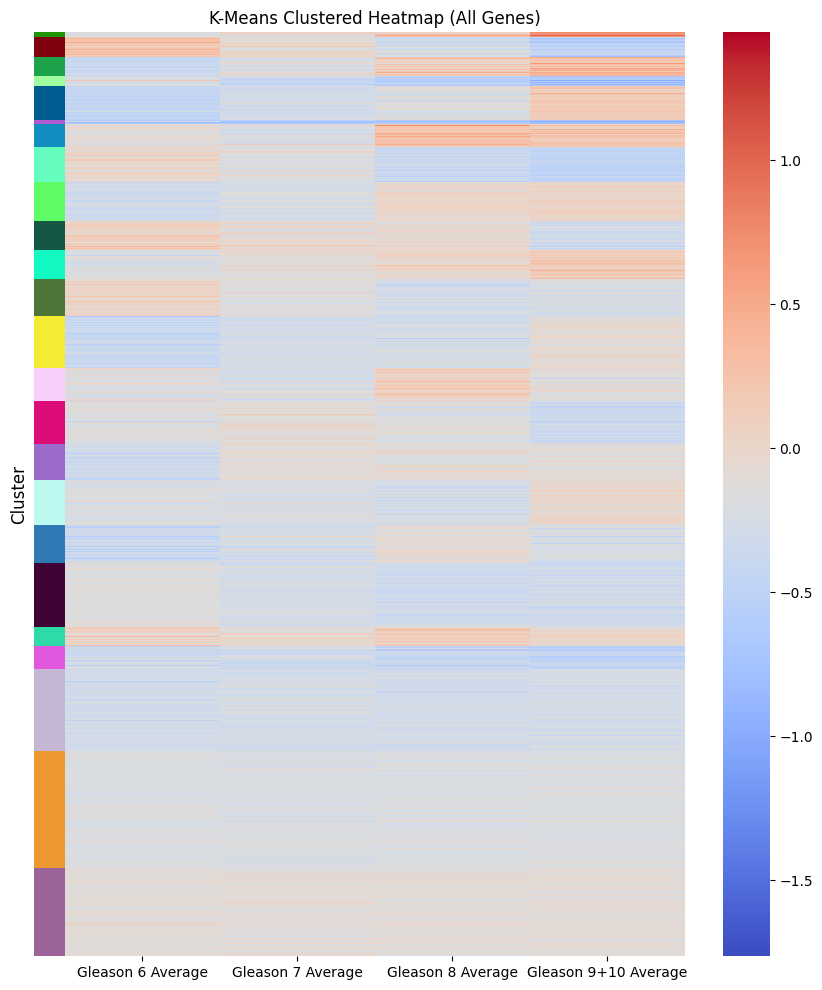

In [60]:
from matplotlib.colors import ListedColormap

# Reorder full dataset by new cluster labels
data_sorted = average_data.sort_values(by="Cluster")

# Get the number of unique clusters
num_clusters = data_sorted["Cluster"].nunique()

# Generate a random colormap for clusters
random_colors = np.random.rand(num_clusters, 3)  # Random RGB colors
cluster_cmap = ListedColormap(random_colors)  # Create colormap

# Create a figure for both heatmaps
plt.figure(figsize=(10, 12))

# Create a main heatmap for the data (without the cluster column)
sns.heatmap(data_sorted.drop(columns=["Cluster"]), cmap="coolwarm", xticklabels=True, yticklabels=False)

# Create an inset axis for the color bar (cluster labels)
cbar_ax = plt.gca().inset_axes([-0.05, 0, 0.05, 1])  # Thin vertical color bar on the left side

# Plot the cluster labels as a heatmap on the left side using the random colormap
sns.heatmap(data_sorted[['Cluster']], cmap=cluster_cmap, cbar=False, xticklabels=False, yticklabels=False, ax=cbar_ax)

# Add y-axis label for the inset color bar
cbar_ax.set_ylabel('Cluster', fontsize=12)

# Remove any index column label (this is likely where "Unnamed: 0" comes from)
plt.gca().set_ylabel("")  # This removes the y-axis label on the second heatmap

# Adjust layout and finalize the plot
plt.title("K-Means Clustered Heatmap (All Genes)")
plt.show()

In [61]:
# Getting rid of semi-colons for Enrichr

list_of_clusters = []
for cluster_num in range(1, num_clusters + 1): 
    genes_in_cluster = average_data[average_data["Cluster"] == cluster_num].index.to_list()
    list_of_clusters.append(genes_in_cluster)
    
j = 1
for cluster in list_of_clusters:
    i = 0
    while i < len(cluster):
        if ';' in cluster[i]:
            split_genes = cluster[i].split(';')
            cluster[i:i+1] = split_genes  # Replace the original gene with the split genes
            i += len(split_genes) - 1  # Skip over the new elements added
        i+=1
#     print(f"Cluster {j}:")
#     print(cluster)
    print(f"Cluster {j} length: " + str(len(cluster)))
    j+=1
    

Cluster 1 length: 94
Cluster 2 length: 390
Cluster 3 length: 382
Cluster 4 length: 194
Cluster 5 length: 680
Cluster 6 length: 77
Cluster 7 length: 467
Cluster 8 length: 691
Cluster 9 length: 774
Cluster 10 length: 590
Cluster 11 length: 567
Cluster 12 length: 749
Cluster 13 length: 1027
Cluster 14 length: 659
Cluster 15 length: 866
Cluster 16 length: 711
Cluster 17 length: 890
Cluster 18 length: 754
Cluster 19 length: 1275
Cluster 20 length: 381
Cluster 21 length: 451
Cluster 22 length: 1646
Cluster 23 length: 2320
Cluster 24 length: 1762


# Over-representation Analysis

In [22]:
import gseapy as gp
# human = gp.get_library_name(organism='Human')

# for geneset_library in human:
#     if "hallmark" in geneset_library.lower():
#         print(geneset_library)

# library = gp.get_library(name="GO_Biological_Process_2025", organism="Human")
# print(library.keys())

In [63]:
from IPython.display import display, HTML

cluster = list_of_clusters[0]
print(f"Cluster size: {len(cluster)}")
print()
print(cluster)

enr = gp.enrich(gene_list=cluster, # or gene_list=glist
                 gene_sets=["data/bp_2024.gmt", "data/cc_2024.gmt", "data/mf_2024.gmt", "data/hallmark_2024.gmt", "data/onc_2024.gmt", "data/im_2024.gmt"], # kegg is a dict object
                 background=data.index.to_list(),
                 outdir=None,
                 verbose=False)

display(HTML(enr.results.loc[enr.results["Adjusted P-value"] < 0.05].sort_values(by='Adjusted P-value').to_html()))

Cluster size: 94

['ACTL6A', 'ANKRD46', 'ARHGAP39', 'ARMC1', 'ATAD2', 'ATP6V1C1', 'AZIN1', 'FAM220A', 'NDUFAF6', 'C8orf76', 'TRIQK', 'CCNE2', 'CHCHD3', 'CHMP4C', 'CHRAC1', 'COPS5', 'CSPP1', 'CUL1', 'STEEP1', 'DCAF13', 'DECR1', 'DERL1', 'DSCC1', 'DVL3', 'E2F5', 'EBAG9', 'ENY2', 'ESRP1', 'ZC2HC1A', 'FAM49B', 'RMDN1', 'FAM83H', 'FAM91A1', 'FBXO43', 'GRINA', 'HSF1', 'IMPA1', 'INTS8', 'ISY1', 'KIAA0196', 'KIAA1429', 'MAL2', 'MBD4', 'MTBP', 'MTDH', 'MTERF3', 'TONSL', 'NSMCE2', 'NUDCD1', 'NUPL2', 'OSGIN2', 'OTUD6B', 'PABPC1', 'PDCD10', 'PHF20L1', 'PIP5K1A', 'POLR2K', 'PTDSS1', 'PTK2', 'RAD21', 'RAD54B', 'RIPK2', 'RNF139', 'RNF19A', 'RRS1', 'RSRC1', 'RYK', 'SCRIB', 'SLC25A32', 'STAU2', 'SUN1', 'TAF2', 'TATDN1', 'TCEB1', 'TERF1', 'TMEM65', 'TMEM70', 'TPD52', 'TRMT12', 'TSNARE1', 'EMC2', 'UBE2V2', 'UTP23', 'WWP1', 'YWHAZ', 'ZC3H3', 'ZFAND1', 'ZFP41', 'ZNF16', 'ZNF251', 'ZNF696', 'ZNF706', 'ZNF707', 'ZNF7']


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
2986,im_2024.gmt,GSE18804_BRAIN_VS_COLON_TUMORAL_MACROPHAGE_DN,23/175,2.005344e-26,6.264694e-23,39.105422,2313.922473,RAD21;E2F5;COPS5;SLC25A32;DCAF13;NSMCE2;TRMT12;RNF139;PHF20L1;ATAD2;NUDCD1;NDUFAF6;SCRIB;DSCC1;CHMP4C;INTS8;C8orf76;YWHAZ;PABPC1;FAM91A1;EBAG9;ZNF696;IMPA1
4727,im_2024.gmt,GSE45365_CTRL_VS_MCMV_INFECTION_NK_CELL_DN,22/167,2.614572e-25,4.083962e-22,38.716317,2191.480094,RAD21;UTP23;COPS5;TERF1;DCAF13;NSMCE2;TRMT12;RNF139;PHF20L1;DERL1;ATAD2;NDUFAF6;SCRIB;DSCC1;ARMC1;CHMP4C;ENY2;INTS8;C8orf76;PTK2;EBAG9;IMPA1
4724,im_2024.gmt,GSE45365_CD8A_DC_VS_CD11B_DC_IFNAR_KO_DN,14/172,2.091789e-13,2.178250e-10,20.613143,601.812808,CHMP4C;RAD21;DCAF13;ZNF16;PTK2;TAF2;ZFAND1;NSMCE2;FAM91A1;TATDN1;NDUFAF6;RNF139;EBAG9;PHF20L1
2987,im_2024.gmt,GSE18804_SPLEEN_MACROPHAGE_VS_BRAIN_TUMORAL_MACROPHAGE_DN,9/172,2.389907e-07,1.866518e-04,12.323140,187.888951,ARMC1;ESRP1;TERF1;UBE2V2;ANKRD46;NSMCE2;RNF139;PHF20L1;DSCC1
4723,im_2024.gmt,GSE45365_CD8A_DC_VS_CD11B_DC_DN,8/178,3.606641e-06,2.253429e-03,10.447019,130.929708,DCAF13;UBE2V2;DERL1;ANKRD46;NSMCE2;TATDN1;PDCD10;EBAG9
1560,cc_2024.gmt,GOCC_CHROMOSOMAL_REGION,10/350,1.201667e-05,2.932067e-03,6.552955,74.239838,CHMP4C;MTBP;RAD21;TERF1;HSF1;ACTL6A;NSMCE2;CHRAC1;SUN1;DSCC1
735,bp_2024.gmt,GOBP_ORGANELLE_FISSION,12/460,3.878198e-06,2.966822e-03,6.029695,75.130842,CHMP4C;MTBP;FBXO43;RAD21;TERF1;DCAF13;RMDN1;RAD54B;RRS1;NSMCE2;SUN1;CCNE2
706,bp_2024.gmt,GOBP_NUCLEAR_CHROMOSOME_SEGREGATION,10/299,3.010416e-06,2.966822e-03,7.729252,98.265316,CHMP4C;RAD21;TERF1;DCAF13;RMDN1;ACTL6A;RRS1;NSMCE2;SUN1;CCNE2
130,bp_2024.gmt,GOBP_CELL_CYCLE,22/1518,6.047869e-06,3.084413e-03,3.484095,41.864205,MTBP;RAD21;COPS5;OSGIN2;FBXO43;TERF1;DCAF13;ZNF16;HSF1;RAD54B;CUL1;RRS1;NSMCE2;SUN1;CCNE2;TAF2;CSPP1;SCRIB;DSCC1;CHMP4C;ACTL6A;RMDN1
738,bp_2024.gmt,GOBP_ORGANELLE_LOCALIZATION,12/564,2.979408e-05,8.274734e-03,4.866173,50.711367,ARMC1;CHMP4C;TERF1;COPS5;RMDN1;YWHAZ;RRS1;FAM91A1;SUN1;TSNARE1;PDCD10;SCRIB


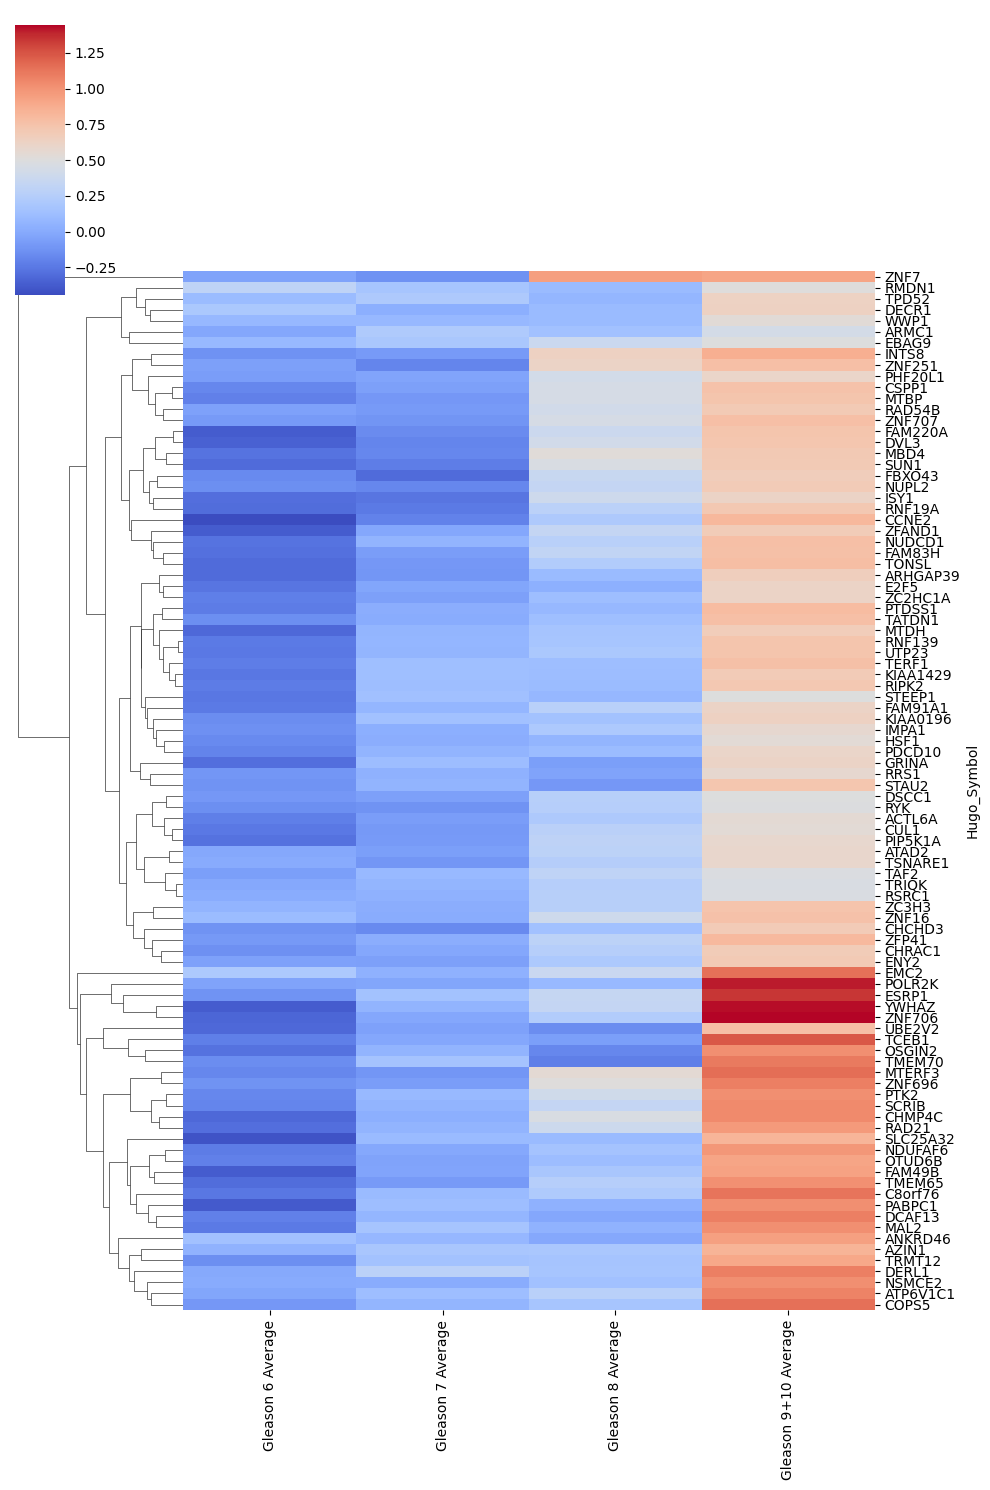

In [73]:
sns.clustermap(data_sorted.loc[cluster].drop(columns=["Cluster"]), cmap="coolwarm", xticklabels=True, yticklabels=True, annot=False, col_cluster = False, figsize=(10, 15))


In [65]:
adjusted_c1.columns = ["1"] * len(adjusted_c1.columns)
adjusted_c2.columns = ["2"] * len(adjusted_c2.columns)
adjusted_c3.columns = ["3"] * len(adjusted_c3.columns)
adjusted_c4.columns = ["4"] * len(adjusted_c4.columns)
# adjusted_c5.columns = ["5"] * len(adjusted_c5.columns)
print(adjusted_c1.head())

                  1       1       1       1       1       1       1       1  \
Hugo_Symbol                                                                   
UBE2Q2P2    -0.0083 -0.2773 -0.0837 -0.0076 -0.1070 -0.9472 -0.5842 -0.6169   
SSX9        -0.0474 -0.0474 -0.0474 -0.0474 -0.0474 -0.0474 -0.0474 -0.0474   
EZHIP       -0.3584 -0.2411  1.0813  1.7024  0.2327 -0.5013 -0.2337 -0.7616   
EFCAB8      -0.1967 -0.1012 -0.2167 -0.4290  0.1437 -0.1291 -0.2770 -0.4290   
SDR16C6P    -0.1839 -0.1839 -0.1839 -0.1839 -0.1839 -0.1839 -0.1839 -0.1839   

                  1       1  ...       1       1       1       1       1  \
Hugo_Symbol                  ...                                           
UBE2Q2P2    -0.6820 -1.1589  ...  0.0448 -0.1727  0.3472 -0.4844 -0.7928   
SSX9        -0.0474 -0.0474  ... -0.0474 -0.0474 -0.0474 -0.0474 -0.0474   
EZHIP       -0.0977  1.5182  ... -0.7616 -0.7616 -0.2147  0.4590 -0.2147   
EFCAB8       0.1447 -0.4290  ... -0.1028 -0.2805  0.5573  0.2741  

c:\Users\tkhan0770\Documents\Dr_Hussain_Lab_Repos\.conda\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


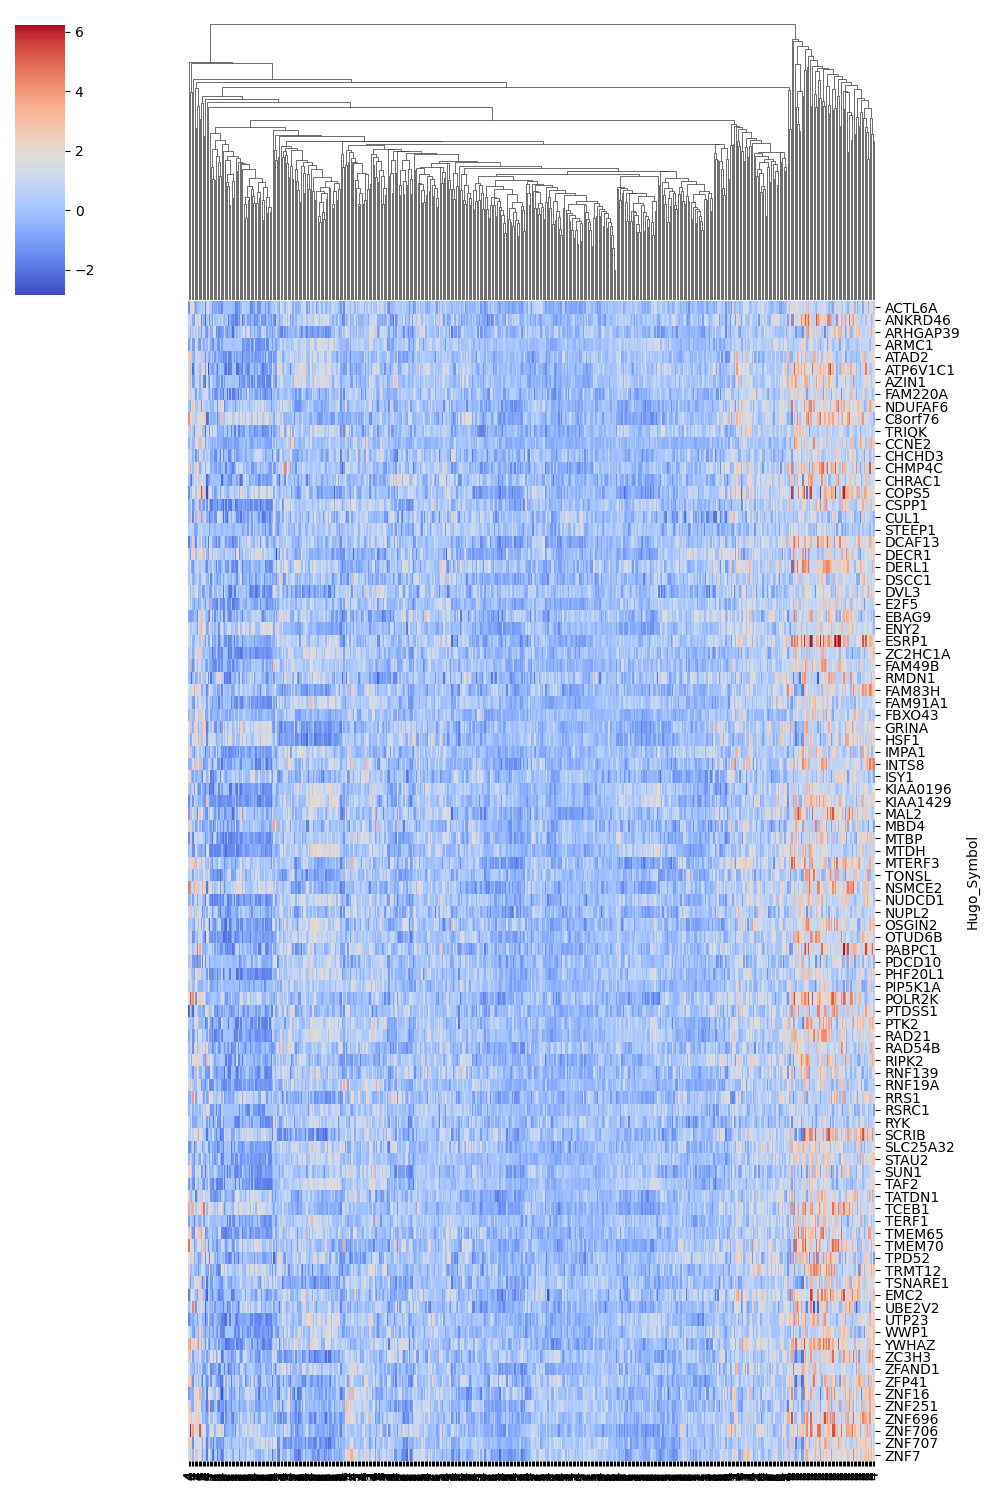

In [74]:
parent_bchem = pd.DataFrame()
parent_bchem = pd.concat([adjusted_c1, adjusted_c2, adjusted_c3, adjusted_c4], axis = 1)
drop_cols = [col for col in parent_bchem.columns if "Average" in col]
parent_bchem = parent_bchem.drop(columns = drop_cols, axis=1)
# print(parent_bchem.head())
sns.clustermap(parent_bchem.loc[cluster], cmap="coolwarm", xticklabels=True, yticklabels=True, annot=False, row_cluster=False, figsize=(10, 15))

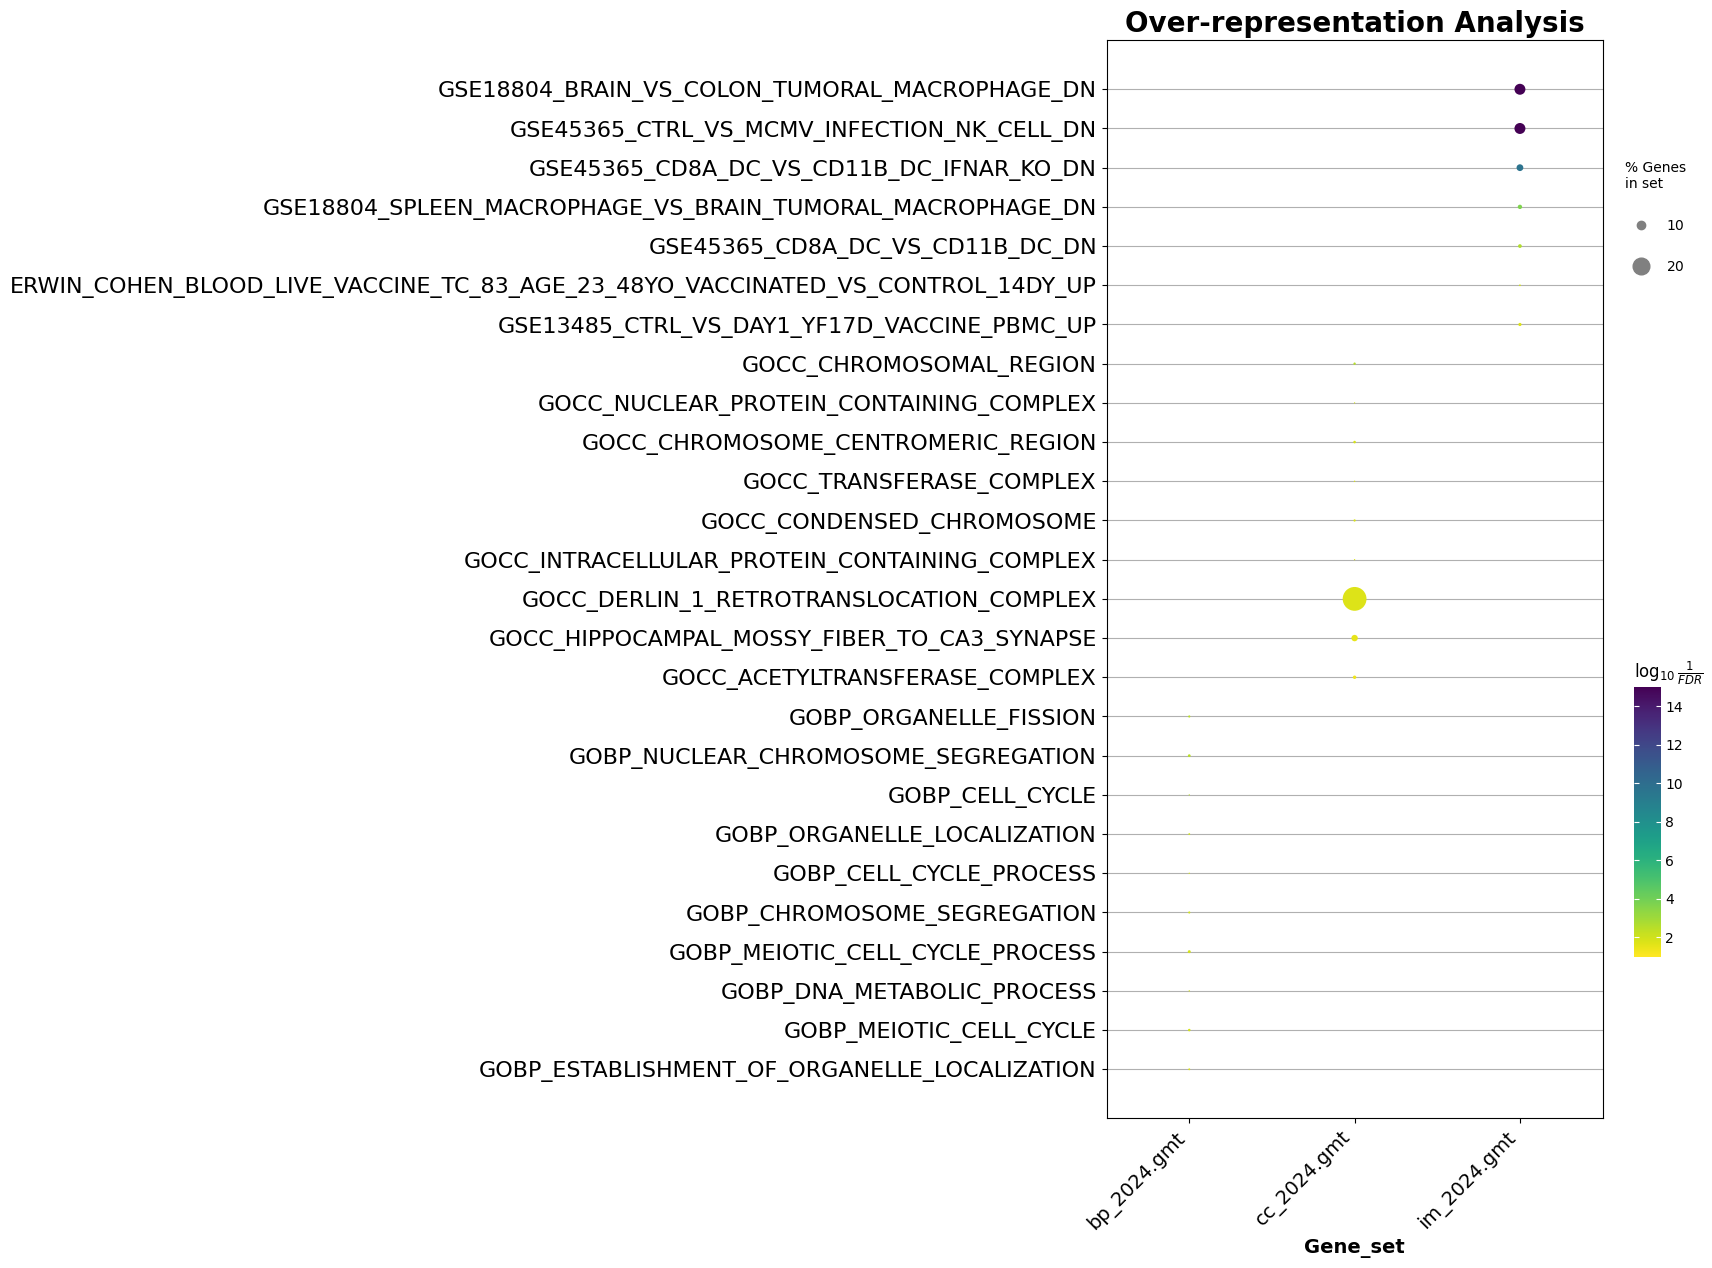

In [75]:
from gseapy import barplot, dotplot
ax = dotplot(enr.results,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=10,
              top_term=10,
              figsize=(8,14),
              title = "Over-representation Analysis",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=False, # set to False to revmove outer ring
              marker='o',
             )

In [76]:
parent_bchem_T = parent_bchem.loc[cluster].T
print(parent_bchem_T.head())
# # Remove columns with repeated names
# total_data = data.loc[:, ~parent_bchem.columns.duplicated()]

# # Drop non-numeric columns (assuming the first 3 columns are metadata)
# gene_expression = total_data.iloc[:, 0:]  # Exclude the label column

# Convert to numpy array
parent_bchem_T_vals = parent_bchem_T.values

print(parent_bchem_T_vals)

Hugo_Symbol  ACTL6A  ANKRD46  ARHGAP39   ARMC1   ATAD2  ATP6V1C1   AZIN1  \
1           -0.7010   0.7815   -0.3198 -0.5661  0.6545   -0.7016  0.1037   
1           -0.5769   0.5101   -1.1014 -0.5320 -0.2258    0.3184 -0.2905   
1           -0.2456   0.9676    1.2130  0.3182  0.6649    0.1548 -0.2640   
1            0.0407   0.2209   -0.5681 -0.1174 -0.3803    0.0264 -0.0800   
1            0.8729  -0.3735    0.6533 -0.0223 -0.4495   -0.2654 -0.3082   

Hugo_Symbol  FAM220A  NDUFAF6  C8orf76  ...   YWHAZ   ZC3H3  ZFAND1   ZFP41  \
1            -0.9790  -0.8921   0.1808  ...  0.3558  1.1510 -0.3835 -0.2662   
1            -0.1309  -0.1279  -0.3431  ... -0.5812  0.3155  0.0673 -0.9456   
1            -0.9846  -0.0140   0.4837  ...  0.3308  0.9448  0.3139 -0.5360   
1             0.6531  -0.1861   0.4129  ... -0.0894  0.8443 -0.8124 -1.0576   
1             0.0990   0.2355   0.1582  ...  0.0486 -0.0060  0.9093  0.8784   

Hugo_Symbol   ZNF16  ZNF251  ZNF696  ZNF706  ZNF707    ZNF7  
1     

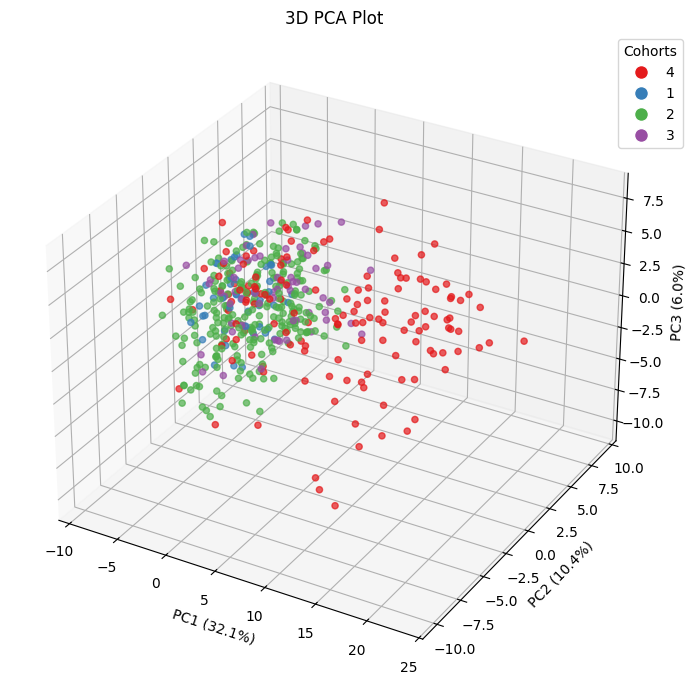

In [77]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA(n_components=3)
gene_expression_pca = pca.fit_transform(parent_bchem_T_vals)

# Get % variance explained
explained_var = pca.explained_variance_ratio_ * 100  # convert to percent

# Get cohort labels
cohorts = parent_bchem.columns
unique_labels = list(set(cohorts))
color_map = {label: color for label, color in zip(unique_labels, plt.cm.Set1.colors)}
colors = cohorts.map(color_map)

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot PCA
scatter = ax.scatter(
    gene_expression_pca[:, 0],
    gene_expression_pca[:, 1],
    gene_expression_pca[:, 2],
    c=colors, alpha=0.7
)

ax.set_xlabel(f'PC1 ({explained_var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_var[2]:.1f}%)')
ax.set_title('3D PCA Plot')

# Legend
legend_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
    for label, color in color_map.items()
]
ax.legend(handles=legend_patches, title='Cohorts', loc='best', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


C:\Users\tkhan0770\AppData\Local\Temp\ipykernel_35044\2152845138.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap("Set1", len(unique_labels))


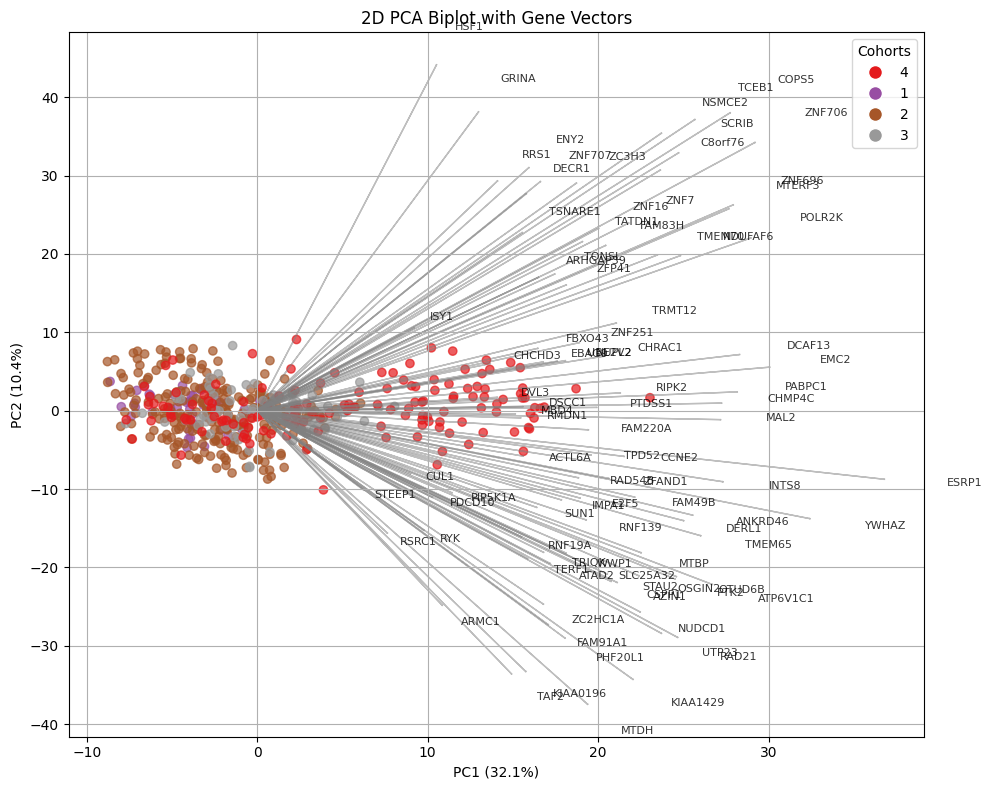

In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# Run PCA on the transposed data (samples as rows)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(parent_bchem_T_vals)

# Get variance explained
explained_var = pca.explained_variance_ratio_ * 100

# Get cohorts and assign high-contrast colors
cohorts = parent_bchem.columns
unique_labels = list(set(cohorts))
colormap = plt.cm.get_cmap("Set1", len(unique_labels))
color_map = {label: colormap(i) for i, label in enumerate(unique_labels)}
colors = cohorts.map(color_map)

# Plot 2D scatter plot with PCA results
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, alpha=0.7)

# Axis labels
ax.set_xlabel(f'PC1 ({explained_var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]:.1f}%)')
ax.set_title('2D PCA Biplot with Gene Vectors')

# Add gene vectors (loadings)
loadings = pca.components_.T  # shape: (n_genes, 2)
genes = parent_bchem_T.columns  # gene names

# Scale vectors for visibility
scale_factor = 200

for i, gene in enumerate(genes):
    ax.arrow(0, 0, 
             loadings[i, 0] * scale_factor, 
             loadings[i, 1] * scale_factor, 
             color='gray', alpha=0.5, head_width=0.05)
    ax.text(loadings[i, 0] * scale_factor * 1.1, 
            loadings[i, 1] * scale_factor * 1.1, 
            gene, fontsize=8, alpha=0.8)

# Custom legend
legend_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label=label, 
               markersize=10, markerfacecolor=color)
    for label, color in color_map.items()
]
ax.legend(handles=legend_patches, title='Cohorts', loc='best')

plt.grid(True)
plt.tight_layout()
plt.show()


In [79]:
print(len(parent_bchem.columns))

# print the top 10 genes that contribute to pc1

# Get the loadings for PC1
pc1_loadings = pca.components_[0]

# Create a DataFrame with genes and their corresponding loadings
pc1_contributions = pd.DataFrame({
    'Gene': parent_bchem_T.columns,
    'Contribution': pc1_loadings
})

# Sort by absolute contribution and get the top 10 genes
top_10_genes = pc1_contributions.reindex(pc1_contributions.Contribution.abs().sort_values(ascending=False).index).head(10)

print(top_10_genes)


501
      Gene  Contribution
27   ESRP1      0.183787
84   YWHAZ      0.161976
80    EMC2      0.150145
91  ZNF706      0.145933
56  POLR2K      0.144678
19  DCAF13      0.141314
52  PABPC1      0.140621
90  ZNF696      0.139516
15   COPS5      0.138634
45  MTERF3      0.138237


2025-07-30 12:26:58,436 [WARNING] Duplicated values found in preranked stats: 5.97% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,tag %,gene %,fdr,es,nes,lead_genes
0,onc_2024.gmt__RB_P107_DN.V1_UP,66/125,13.77%,0.000000,-0.639728,-2.333929,CCNE2;PRC1;COL1A2;COL1A1;CHAF1B;GINS4;BGN;KIF4A;RRM1;SRPX2;RFC2;COL5A1;STMN1;SLBP;DHFR;CDC45;GTSE1;TMEM119;MCM2;TCF19;RRM2;DNAJC9;TCFL5;NAA40;ASF1B;RPA3;TRPV2;GMNN;LIG1;MCM6;NCAPH;CDC25B;CDH11;E2F1;MAD2L1;FBN1;PCNA;ORC6;RFC5;RHEBL1;KHDRBS3;WDHD1;FANCA;INCENP;PTMA;MCM7;MCM5;COX6B2;NRM;CCNE1;MFGE8;COL16A1;IPO9;E2F8;FKBP10;LOXL1;FSTL1;FBLN2;FEN1;POLD1;CCNF;CENPH;RPA2;BICC1;PCOLCE;CENPK
1,onc_2024.gmt__VEGF_A_UP.V1_DN,95/188,25.21%,0.000000,-0.473135,-1.851061,CTNNAL1;MBD4;SMC4;TGFBI;CKS2;TMPO;HMMR;STIP1;CDKN3;DLGAP5;KIF23;DHFR;CSE1L;CDC45;TTK;SPAG5;RRM2;BUB1;LMNB1;MCM4;RFC4;CENPA;CCNB2;RRS1;BUB1B;RGS5;CENPE;RECQL;NRP1;CEP170;KIF11;MAD2L1;CBL;HIRA;PLK4;CCNB1;PTPRE;MACIR;MMP14;BIRC5;EXO1;NCOA3;CCNE1;ANGPT2;VRK1;EIF2S3;NBN;SAT1;USP13;B4GALT5;ZNF124;BAK1;ATP13A3;ZNF253;CEP131;PRMT3;MAP1B;NDC80;DBF4;MFAP3;MYO5A;ZC3H15;MAPK6;PNN;MEST;POP1;MRPL19;ORC2;PPIG;GPR4;DDX21;PNO1;GPR37;NUP155;ATIC;PRPF40A;CDC27;RAP1A;ATP8B3;ASPH;RASA2;NOC2L;DNAJC13;RP2;RRP12;SCAF11;RIF1;AIMP1;STEAP1;TWF1;MAFK;CCDC86;TFAM;NEK7;PAPOLA
2,onc_2024.gmt__E2F1_UP.V1_UP,68/173,17.14%,0.000000,-0.513199,-2.039202,CDV3;PRC1;ARHGAP39;AGO2;CHAF1B;EZH2;UBE2T;RRM1;E2F3;SMC2;DLGAP5;FMNL3;SLC20A1;CDR2L;SLBP;GRSF1;BUB1;LMNB1;MCM4;HMGB3;CAD;TRAF3;DNAJC2;USP39;TYMS;POLA2;TK1;PARP1;KIFC1;PITPNM1;TOP2A;NCAPH;MAPK14;ADA;LPIN2;TPD52;PKP4;PLK4;WDHD1;TBP;PIGA;MCM10;AURKB;E2F8;SIRPA;BRCA2;FEN1;TAF6;FANCM;CNIH2;NASP;NAB1;TRNT1;ARF3;DNAJC21;TLE4;RRP1B;ELAVL1;PACS1;RELL1;DNA2;DBF4;PIP4K2A;MAP3K3;FNBP1;PARP16;USF2;STIL
3,onc_2024.gmt__GCNP_SHH_UP_EARLY.V1_UP,64/161,16.00%,0.000000,-0.548724,-2.205570,FAM220A;PRC1;PHTF2;SPDL1;AURKA;NUP107;UBE2T;KIF4A;RRM1;IRF5;E2F3;CKS2;SMC2;AZIN1;ANLN;DHFR;MSH6;RYK;GPATCH2;TYMS;MATR3;POLA2;KIFC1;MCM6;TOP2A;LOXL2;LUC7L2;MAPK14;MTA1;MRPL50;SRSF1;SRSF10;CSF1;MCM5;VHL;CXorf38;EPB41L4B;XPO1;TRAIP;TBP;MCM10;NAP1L1;LBR;CD276;AURKB;E2F8;RBBP6;SLC23A2;ABCB10;NVL;GNL3;CNOT2;FEN1;FIP1L1;LUC7L3;UPF3B;ICAM5;RHPN2;RLIM;NABP1;TMEM250;TOP2B;STAG2;SHC1
4,onc_2024.gmt__GCNP_SHH_UP_LATE.V1_UP,62/168,13.23%,0.000000,-0.536730,-2.124624,TRIP13;PRC1;PHTF2;AURKA;SMC4;RRM1;CKS2;SMC2;DLGAP5;RRM2;SLC29A1;VCAN;NUSAP1;MCM4;CDK1;CDC25C;PCNT;ATAD2B;FANCC;RYK;USP39;MATR3;POLA2;TK1;UNG;KIFC1;TIMM8A;DDX39A;LIG1;MCM6;TOP2A;LOXL2;HNRNPU;HIGD1A;KIF2C;SRSF1;SRSF10;INCENP;MCM5;XPO1;CD80;MCM10;PLEKHA7;DIDO1;LBR;PLK2;AURKB;E2F8;PSMC3IP;YTHDF3;GART;SIX4;SLC23A2;TARDBP;GNL3;NAA15;NPM1;LUC7L3;FANCM;NTMT1;ABCE1;C1orf174
5,onc_2024.gmt__CSR_LATE_UP.V1_UP,56/159,17.52%,0.002704,-0.463697,-1.777872,NUDCD1;TRIP13;EZH2;UBE2C;MYBL2;ANLN;ACTL6A;NUF2;TCF19;POLE3;RRM2;ZNF367;LTBP2;TMEM130;UMPS;CDK1;MCM3;UTP18;SHCBP1;FAM83D;ASB6;CTPS1;GMNN;IGFBP3;FOXM1;CDCA8;RAD18;PSMD2;GINS3;CDC6;LMNB2;PBK;ZWINT;CASP2;FANCA;AP1S2;BIRC5;TSPAN13;DRAP1;WSB2;CDC7;FEN1;POLD1;NETO2;YEATS4;SNRPA1;SLC16A3;ZWILCH;HAUS2;HIP1;MRAS;PGM2;BHLHE40;ILF2;CLSPN;PSMD14
6,onc_2024.gmt__CSR_EARLY_UP.V1_UP,61/143,17.34%,0.003477,-0.470593,-1.733330,C8orf76;PTPN12;YWHAG;MSANTD3;RIPK2;TDG;GABPB2;POLE3;PHF20L1;KLF13;KPNA4;TFG;EHD4;CTPS1;NCL;ELL;PHLDB1;CD33;ZBTB2;INHBA;GTPBP4;NMD3;TMEM200A;PANX1;VGLL4;FOXD1;CSRNP2;DNAJA1;ELK3;CCDC59;YOD1;TRMT10C;DOT1L;HLX;SNAI1;SMAD7;HMGA1;ACTR3;GNL2;PNP;UTP3;BRPF1;IL11;IRAK1;RRP9;NUP54;PTP4A1;ITPRIPL2;POM121;PLCH1;ETS1;TBX2;ST3GAL1;GATA2;EIF4A3;BDKRB1;FJX1;ZBTB12;ILF2;NOP16;C21orf91
7,onc_2024.gmt__CORDENONSI_YAP_CONSERVED_SIGNATURE,22/52,14.74%,0.006085,-0.525125,-1.693314,MARCKS;HMMR;CENPF;STMN1;FSCN1;CDKN2C;GLS;SHCBP1;TK1;CDC20;TOP2A;ECT2;BIRC5;TGFB2;ASAP1;FSTL1;GAS6;ITGB2;PDLIM2;AXL;BICC1;TGM2
8,onc_2024.gmt__E2F3_UP.V1_UP,55/179,15.62%,0.007212,-0.425591,-1.674941,CCNE2;CHST1;CBX2;GINS1;MEX3B;ZNF367;CABLES2;E2F7;PLXND1;ZFP30;CDKN2C;HEY1;TM6SF1;TSPAN5;UNG;ATAD2;GPR160;TMEM106C;FAM43B;PCNA;SYNGR3;CCP110;CHML;TPPP;KHDRBS3;MNX1;PTCH1;GPR137C;SNX10;FANCA;FOXD1;DCK;DTL;KLF16;RTN4R;CCNE1;TMOD2;ZNF703;FBXL16;SBK1;CSPG5;NOL4L;GAD1;DCLRE1B;ZIC2;FEN1;FGF9;MANEAL;MAP6D1;SHANK3;WNT9A;FAM78A;CRY1;RIPPLY3;ENO2
9

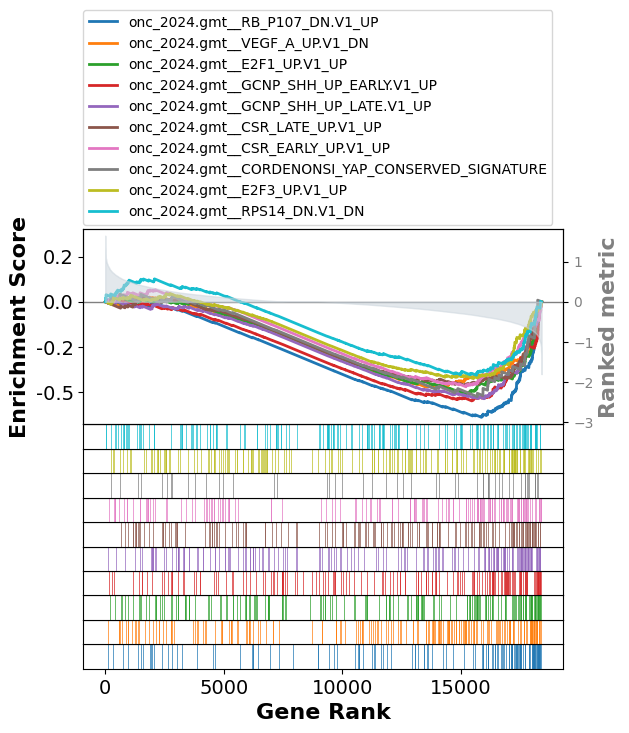

In [82]:
# Create a ranking metric - here using the difference between c4 and c1 averages
expression['ranking_metric'] =  expression['Gleason 6 Average'] - expression['Gleason 9+10 Average']

# Rank genes by this metric
ranking = expression[['ranking_metric']]
ranking = ranking.sort_values(by='ranking_metric', ascending=False)

# Convert to the format gseapy expects (index = gene names, column = ranking)
ranking = ranking.rename_axis("gene").reset_index()

import gseapy as gp

# Path to the gene sets file
gmt_file = "data/hallmark_2024.gmt"  # Update path as needed

pre_res = gp.prerank(rnk = ranking,
                     gene_sets=["data/onc_2024.gmt"], # kegg is a dict object
                     seed = 6, permutation_num = 100)

# gene_sets=["data/bp_2024.gmt", "data/cc_2024.gmt", "data/mf_2024.gmt", "data/hallmark_2024.gmt", "data/onc_2024.gmt", "data/im_2024.gmt"], # kegg is a dict object

out = []

for term in list(pre_res.results):
    out.append([term,
               pre_res.results[term]['tag %'],
               pre_res.results[term]['gene %'],
               pre_res.results[term]['fdr'],
               pre_res.results[term]['es'],
               pre_res.results[term]['nes'],
               pre_res.results[term]['lead_genes']])

out_df = pd.DataFrame(out, columns = ['Term', 'tag %', 'gene %', 'fdr', 'es', 'nes', 'lead_genes']).sort_values('fdr').reset_index(drop = True)
# display(HTML(out_df.to_html()))

axs = pre_res.plot(out_df['Term'][0:10],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

display(HTML(out_df.to_html()))


2025-07-30 12:27:24,908 [WARNING] Found duplicated gene names, values averaged by gene names!


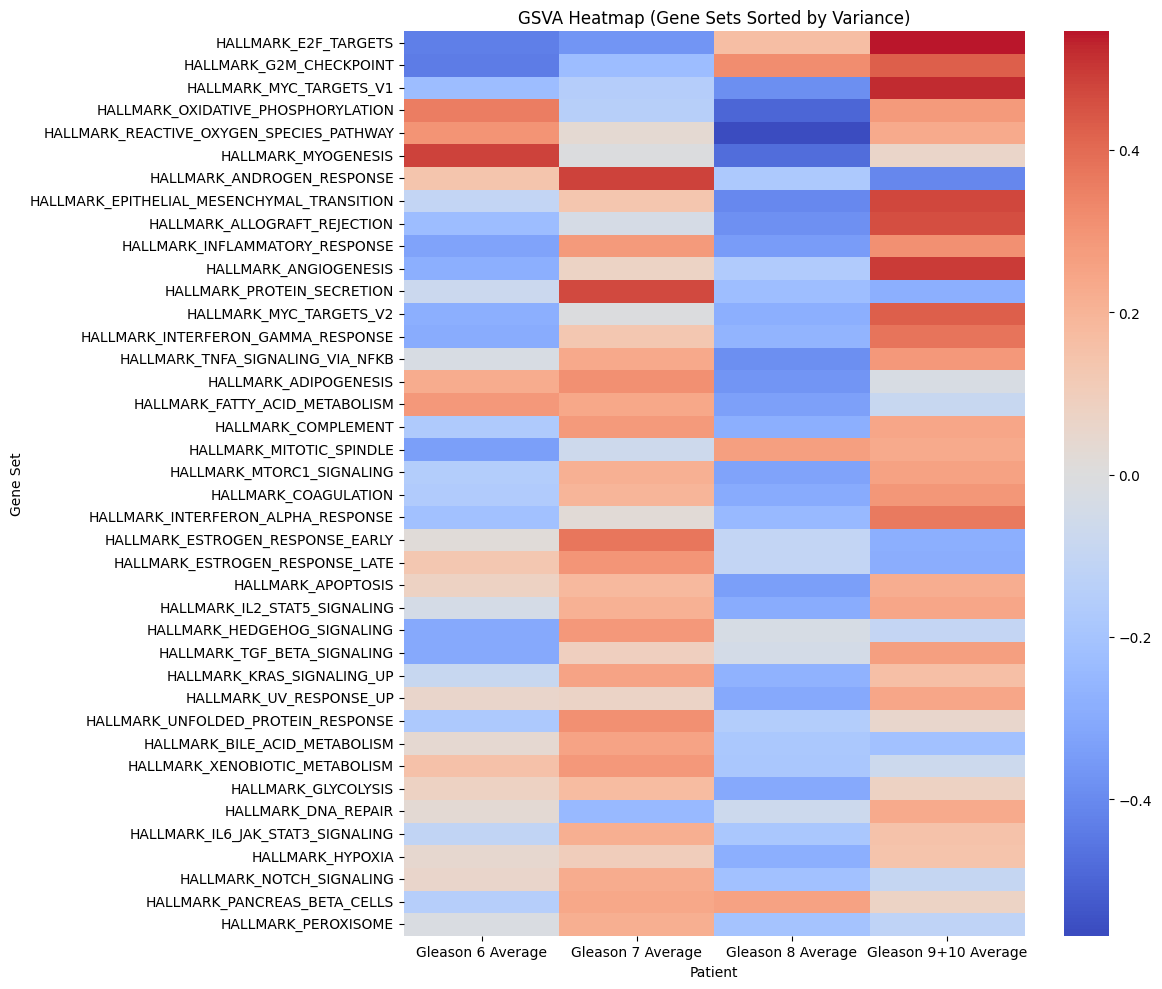

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gseapy as gp

# Drop metadata
original_expression = expression.drop(columns=["ranking_metric"])

# Run GSVA
es = gp.gsva(data=original_expression,
             gene_sets='data/hallmark_2024.gmt',
             outdir=None)

# Pivot to gene sets × patients matrix
es_matrix = es.res2d.pivot(index='Term', columns='Name', values='ES')

# Convert to float and drop NaNs just in case
es_matrix = es_matrix.astype(float).dropna(axis=0, how='any')

# Sort gene sets by row variance
es_matrix['Variance'] = es_matrix.var(axis=1)
es_matrix_sorted = es_matrix.sort_values(by='Variance', ascending=False).drop(columns='Variance')
top_n = 40
es_matrix_sorted = es_matrix_sorted.head(top_n)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(es_matrix_sorted, cmap='coolwarm', center=0)
plt.title("GSVA Heatmap (Gene Sets Sorted by Variance)")
plt.xlabel("Patient")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()


c:\Users\tkhan0770\Documents\Dr_Hussain_Lab_Repos\.conda\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\tkhan0770\Documents\Dr_Hussain_Lab_Repos\.conda\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


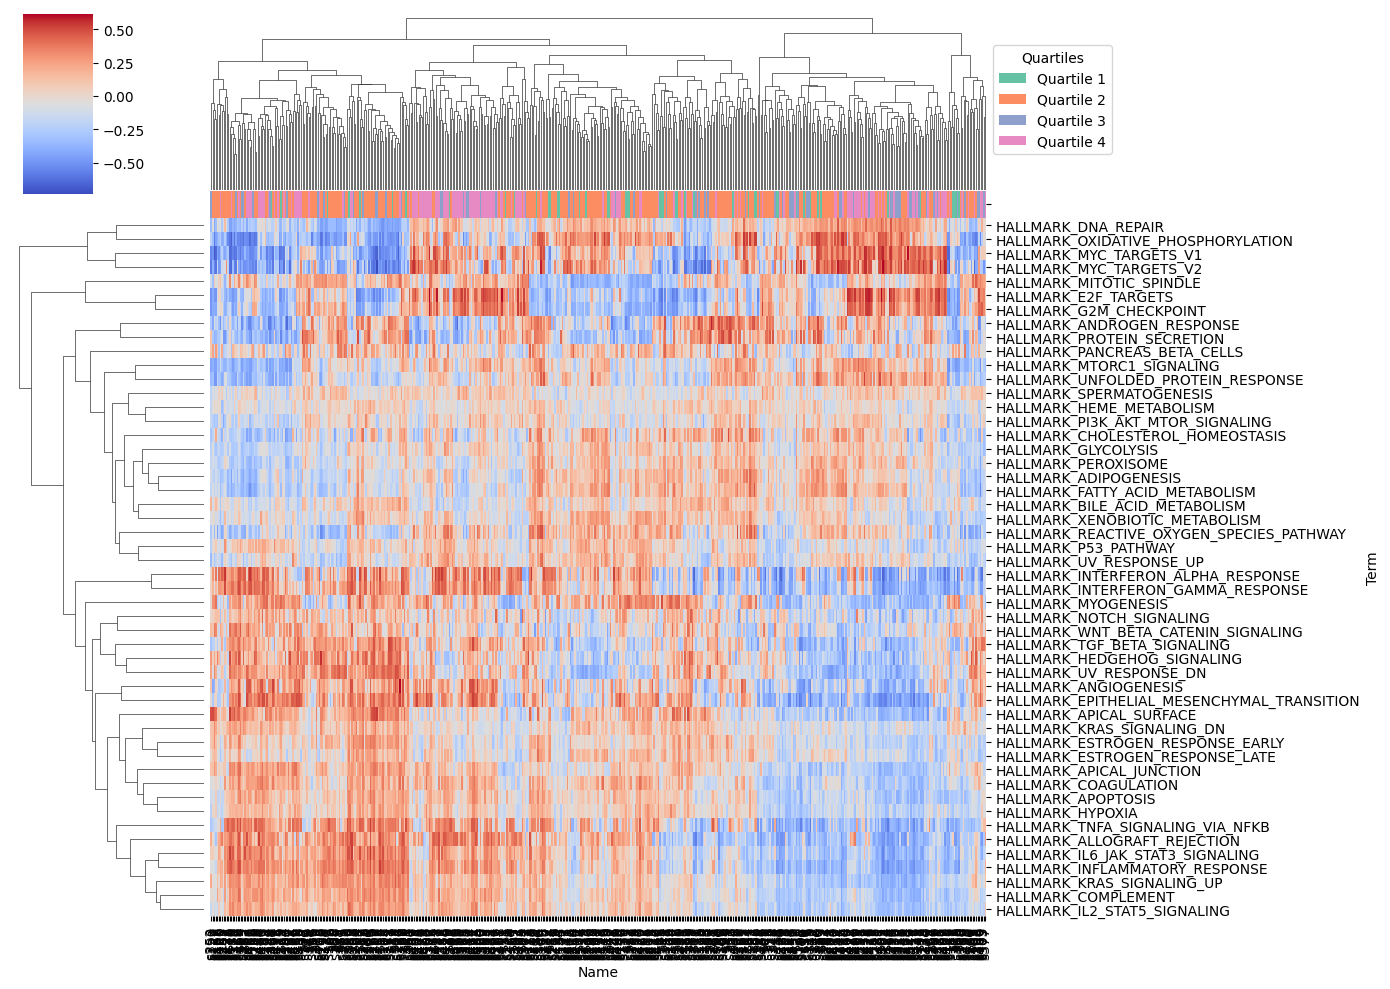

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import gseapy as gp

# Step 1: Rename columns to s1, s2, ..., sN
parent_bchem.columns = [f's{i+1}' for i in range(parent_bchem.shape[1])]

# Step 2: Create list of quartile labels matching sample order
# Assuming adjusted_c1 to adjusted_c4 were defined before and concatenated in that order:
quartile_labels = [1] * adjusted_c1.shape[1] + \
                  [2] * adjusted_c2.shape[1] + \
                  [3] * adjusted_c3.shape[1] + \
                  [4] * adjusted_c4.shape[1]
                #   [5] * adjusted_c5.shape[1]

# Make sure length matches columns
assert len(quartile_labels) == parent_bchem.shape[1], "Mismatch in sample and quartile count!"

# Step 3: Map quartile labels to colors
quartile_palette = sns.color_palette("Set2", 4)
quartile_color_map = dict(zip([1, 2, 3, 4], quartile_palette))
col_colors = pd.Series(quartile_labels, index=parent_bchem.columns).map(quartile_color_map)

# Step 4: Run GSVA (deduplicate first if needed)
parent_bchem = parent_bchem.groupby(parent_bchem.index).mean()

gsva_results = gp.gsva(data=parent_bchem,
                       gene_sets='data/hallmark_2024.gmt',
                       outdir=None)

# Step 5: Pivot GSVA result and convert to matrix
es_matrix = gsva_results.res2d.pivot(index='Term', columns='Name', values='ES')
es_matrix = es_matrix.astype(float).dropna(axis=0, how='any')

# Step 6: Plot clustermap with quartile annotations
g = sns.clustermap(
    es_matrix,
    cmap="coolwarm",
    xticklabels=True,
    yticklabels=True,
    annot=False,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    figsize=(14, 10)
)

# Add quartile legend
legend_elements = [
    Patch(facecolor=quartile_color_map[q], label=f'Quartile {q}') for q in sorted(quartile_color_map)
]
g.ax_col_dendrogram.legend(
    handles=legend_elements,
    title='Quartiles',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)
)

plt.show()


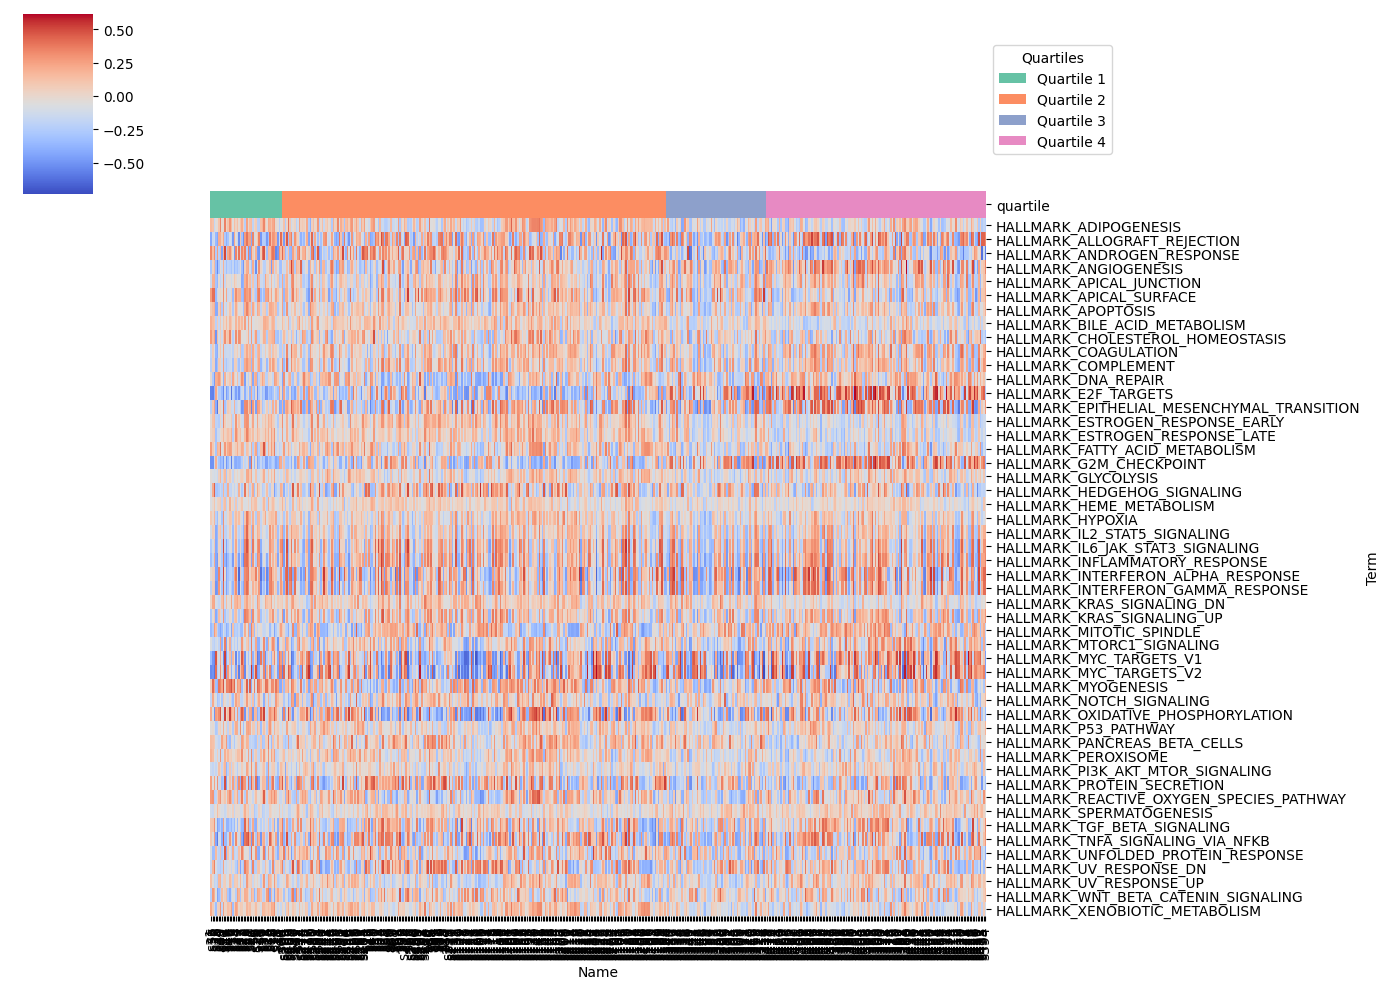

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import gseapy as gp

# Step 1: Rename columns to s1, s2, ..., sN
parent_bchem.columns = [f's{i+1}' for i in range(parent_bchem.shape[1])]

# Step 2: Generate quartile labels
quartile_labels = [1] * adjusted_c1.shape[1] + \
                  [2] * adjusted_c2.shape[1] + \
                  [3] * adjusted_c3.shape[1] + \
                  [4] * adjusted_c4.shape[1]
                #   [5] * adjusted_c5.shape[1]

# Map quartiles to colors
quartile_palette = sns.color_palette("Set2", 4)
quartile_color_map = dict(zip([1, 2, 3, 4], quartile_palette))
quartile_series = pd.Series(quartile_labels, index=parent_bchem.columns, name="quartile")
col_colors = quartile_series.map(quartile_color_map)

# Step 3: Deduplicate genes
parent_bchem = parent_bchem.groupby(parent_bchem.index).mean()

# Step 4: Run GSVA
gsva_results = gp.gsva(data=parent_bchem,
                       gene_sets='data/hallmark_2024.gmt',
                       outdir=None)

# Step 5: Extract GSVA matrix
es_matrix = gsva_results.res2d.pivot(index='Term', columns='Name', values='ES')
es_matrix = es_matrix.astype(float).dropna(axis=0, how='any')

# Step 6: Reorder columns by quartile
quartile_df = pd.DataFrame({
    "sample": es_matrix.columns,
    "quartile": quartile_series[es_matrix.columns].values
})
ordered_samples = quartile_df.sort_values("quartile")["sample"].tolist()

# Reorder matrix and colors
es_matrix = es_matrix[ordered_samples]
col_colors = col_colors[ordered_samples]

# Step 7: Plot WITHOUT clustering
g = sns.clustermap(
    es_matrix,
    cmap="coolwarm",
    xticklabels=True,
    yticklabels=True,
    annot=False,
    row_cluster=False,
    col_cluster=False,
    col_colors=col_colors,
    figsize=(14, 10)
)

# Step 8: Add quartile legend
legend_elements = [
    Patch(facecolor=quartile_color_map[q], label=f'Quartile {q}') for q in sorted(quartile_color_map)
]
g.ax_col_dendrogram.legend(
    handles=legend_elements,
    title='Quartiles',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)
)

plt.show()
